[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_2_Distributions.ipynb)

# 07.2: Distributions of a Single Variable

In 07.1 you saw two histograms and learned that shape is something numbers cannot tell you. This notebook goes deeper. You will learn to control how a histogram is drawn, when to replace it with a smoother alternative, and how to compare distributions across groups. That last step is where the real analytical work begins.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## Bin width is a design choice

A histogram works by dividing the range of values into equal-width intervals called **bins** and counting how many observations fall into each one. The number of bins is something you control, and the choice matters more than you might expect.

Here is the same age data drawn with three different bin counts.

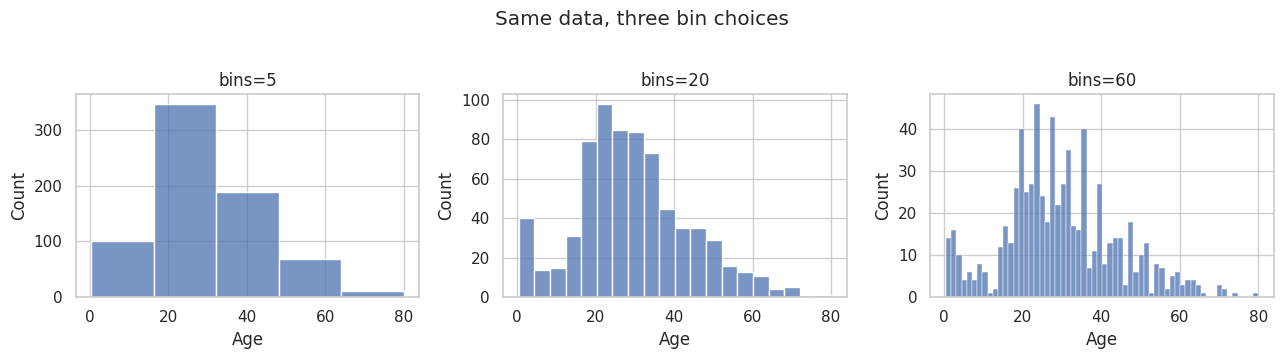

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, bins in zip(axes, [5, 20, 60]):
    sns.histplot(data=df, x="age", bins=bins, ax=ax)
    ax.set_title(f"bins={bins}")
    ax.set_xlabel("Age")

plt.suptitle("Same data, three bin choices", y=1.02)
plt.tight_layout()

With only 5 bins the chart is so coarse that you lose the bump of young children under 10. With 60 bins the bars are so narrow that the chart looks like a noisy scattering of toothpicks. The middle version, 20 bins, strikes a reasonable balance: the overall shape is visible, the secondary peak of children shows up, and the right tail is clear.

There is no universally correct number of bins. A rule of thumb is to aim for bars wide enough to contain at least a handful of observations each. For age data measured in years, setting `binwidth=5` (a 5-year interval) is often more interpretable than specifying a count.

Text(0.5, 0, 'Age (years)')

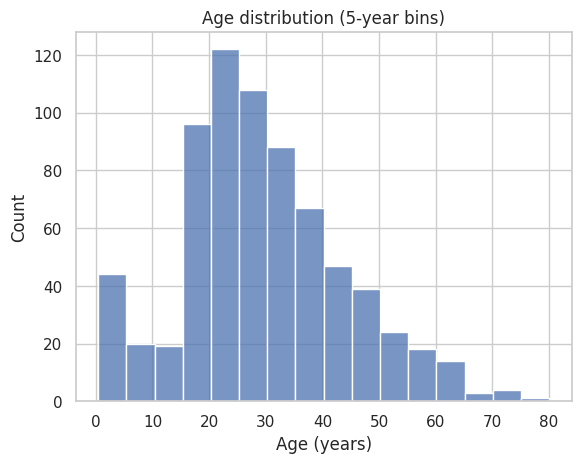

In [3]:
ax = sns.histplot(data=df, x="age", binwidth=5)
ax.set_title("Age distribution (5-year bins)")
ax.set_xlabel("Age (years)")

## When data is skewed: the log scale

The age distribution is roughly symmetric. Fare is different. Most passengers paid under 50 pounds, but a small number paid several hundred. When a distribution has a long tail in one direction, a standard histogram can be hard to read because the rare extreme values compress the main distribution into a narrow sliver.

Text(0.5, 0, 'Fare (pounds)')

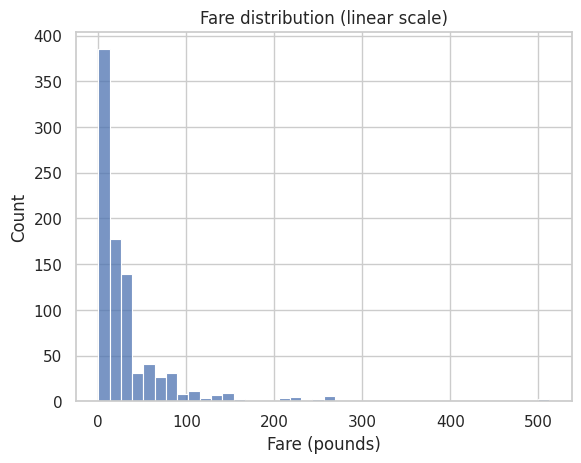

In [4]:
ax = sns.histplot(data=df, x="fare", bins=40)
ax.set_title("Fare distribution (linear scale)")
ax.set_xlabel("Fare (pounds)")

Almost all the mass is piled up near zero. The bars on the right are so thin they are barely visible. This is the visual signature of a **right-skewed** distribution: a few very high values stretch the axis so far that the main bulk of the data gets squashed.

A **log scale** compresses the axis multiplicatively rather than additively. Equal distances on the axis no longer represent equal differences in value; they represent equal ratios. This spreads out the low end and compresses the high end, making both regions readable at once.

Text(0.5, 0, 'Fare (pounds, log scale)')

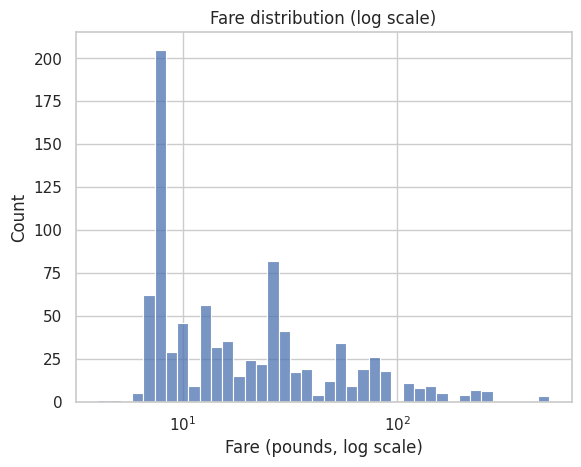

In [5]:
ax = sns.histplot(data=df, x="fare", bins=40, log_scale=True)
ax.set_title("Fare distribution (log scale)")
ax.set_xlabel("Fare (pounds, log scale)")

Now the shape is visible. There are actually two clusters: a large group of passengers who paid roughly 7 to 15 pounds (third class), and a smaller group who paid 20 to 80 pounds (second and first class). The handful of very expensive tickets are no longer dominating the chart.

Use a log scale when your data spans multiple orders of magnitude or has a strong right skew. It does not change the data; it only changes the axis. The x-axis labels (7.5, 10, 100, 512) are still in the original units.

## KDE: smoothing the histogram

A histogram is a jagged approximation of the underlying distribution. Each bar just counts observations in a bin, so the height can jump up or down depending on where the bin boundaries happen to fall. A **kernel density estimate (KDE)** fits a smooth curve through the data instead.

The mechanics: imagine placing a small bell-shaped curve (a kernel) centered on each data point, then summing all those curves. Where points are dense, the curves pile up and the total is high. Where points are sparse, the total is low. The result is a smooth, continuous shape.

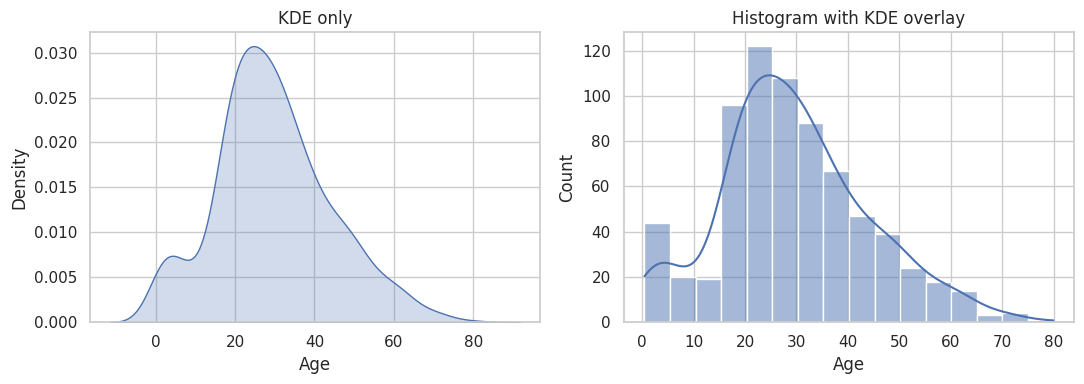

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.kdeplot(data=df, x="age", ax=axes[0], fill=True)
axes[0].set_title("KDE only")
axes[0].set_xlabel("Age")

sns.histplot(data=df, x="age", binwidth=5, kde=True, ax=axes[1])
axes[1].set_title("Histogram with KDE overlay")
axes[1].set_xlabel("Age")

plt.tight_layout()

The KDE and the histogram tell the same story, just in different visual languages. The histogram shows you actual counts (how many passengers). The KDE shows you density (the relative probability of observing a value near each point on the x-axis). When you add `kde=True` to `sns.histplot()`, you get both at once.

The KDE is especially useful for comparisons. When two distributions are layered on top of each other, smooth curves are easier to follow than overlapping bars. You will see this in a moment.

## The box plot: trading shape for summary

Sometimes you do not need to see the full shape. You want a compact answer to: where is the middle, how spread out is it, and are there any outliers? The **box plot** (also called a box-and-whisker plot) answers exactly those questions.

The five components:
- The **box** spans from the 25th to the 75th percentile. This range is called the **interquartile range (IQR)** and contains the middle 50% of the data.
- The line inside the box is the **median** (50th percentile).
- The **whiskers** extend to 1.5 times the IQR beyond the box edges.
- Points beyond the whiskers are plotted individually as **outliers**.

Text(0.5, 0, 'Fare (pounds)')

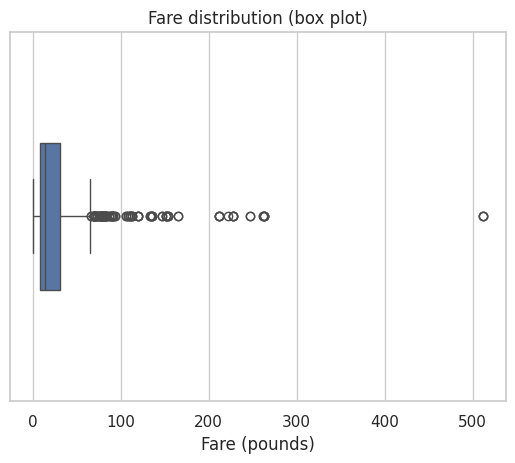

In [7]:
ax = sns.boxplot(data=df, x="fare", width=0.4)
ax.set_title("Fare distribution (box plot)")
ax.set_xlabel("Fare (pounds)")

The box is very narrow (most passengers paid between roughly 7 and 31 pounds) and sits close to zero. The right whisker barely reaches 65 pounds. Everything beyond that is an outlier dot, and there are many of them, stretching all the way to 512 pounds. This is another view of the right skew you saw in the histogram, but compressed into a single graphic.

What the box plot loses: it cannot show you the shape inside the box. You cannot see whether the middle 50% of passengers form a uniform spread or cluster toward one end. For that, you need the histogram or KDE. What the box plot gains: it is compact enough to display many groups side by side. That is where it really shines, and you will use it that way in notebook 07.3.

## The violin plot: shape and summary together

A **violin plot** is a hybrid: a KDE mirrored on both sides, with a miniature box plot embedded inside. You get the smooth shape (from the KDE) and the five-number summary (from the box) in one graphic.

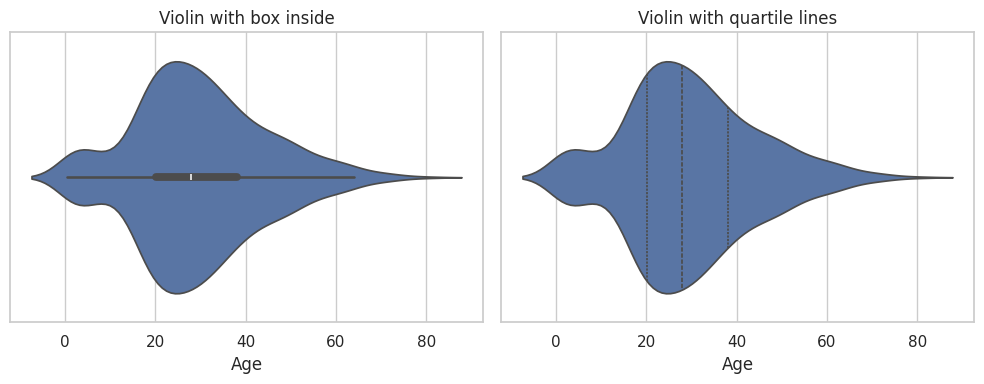

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.violinplot(data=df, x="age", ax=axes[0], inner="box")
axes[0].set_title("Violin with box inside")
axes[0].set_xlabel("Age")

sns.violinplot(data=df, x="age", ax=axes[1], inner="quart")
axes[1].set_title("Violin with quartile lines")
axes[1].set_xlabel("Age")

plt.tight_layout()

The `inner=` parameter controls what appears inside the violin. `"box"` shows the familiar box plot; `"quart"` draws horizontal lines at the quartiles. The wide bulge in the 20s and 30s reflects the peak you saw in the histogram. The slight widening near zero reflects the small cluster of young children.

A rough guide to which chart to reach for:

- **Histogram**: explore one variable in depth; pick bin width to show structure
- **KDE**: compare shapes across groups; smooth line is easier to follow than bars
- **Box plot**: compare summaries across many groups; outliers and spread at a glance
- **Violin**: compare shapes AND summaries; best when sample size is large enough for the KDE to be meaningful

## Comparing distributions across groups

Every chart so far has shown the full passenger population. But the most revealing question is a comparison: did the age distribution differ between survivors and those who did not survive?

Adding `hue="survived"` to any of these charts splits the data by survival status and colors each group differently. The `multiple=` parameter controls how the two groups are displayed.

Text(0.5, 0, 'Age')

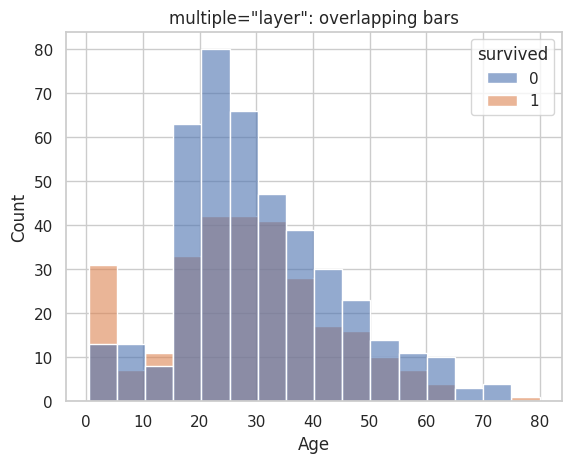

In [9]:
ax = sns.histplot(data=df, x="age", hue="survived", multiple="layer",
                  binwidth=5, alpha=0.6)
ax.set_title('multiple="layer": overlapping bars')
ax.set_xlabel("Age")

Text(0.5, 0, 'Age')

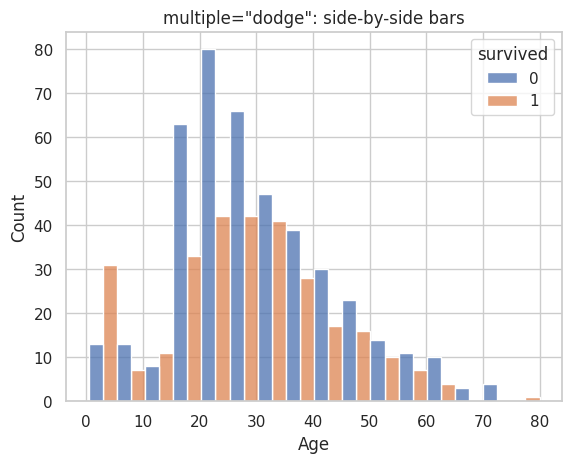

In [10]:
ax = sns.histplot(data=df, x="age", hue="survived", multiple="dodge",
                  binwidth=5)
ax.set_title('multiple="dodge": side-by-side bars')
ax.set_xlabel("Age")

Both views have problems. The layered version is hard to read where the two groups overlap. The dodged version makes each bar half as wide, which washes out the shape. The bars also show raw counts, so the groups are hard to compare directly: there were more non-survivors overall, so their bars are simply taller at every age.

The cleaner solution is a KDE, which shows shape without the bar-width problem, and `common_norm=False`, which normalizes each group independently so you are comparing proportions rather than counts.

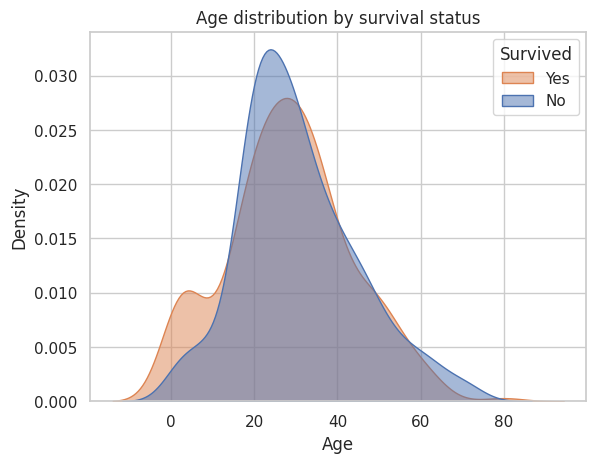

In [11]:
ax = sns.kdeplot(
    data=df, x="age",
    hue="survived",
    fill=True,
    common_norm=False,
    alpha=0.5
)
ax.set_title("Age distribution by survival status")
ax.set_xlabel("Age")
ax.legend(title="Survived", labels=["Yes", "No"])

Now the comparison is clear. Both groups peak in the 20s and 30s, so age alone is not a strong predictor of survival. But the survivor distribution (orange) has a slightly higher proportion of children under 10, which is consistent with the "women and children first" evacuation protocol. The non-survivor distribution (blue) has more mass in the 20 to 40 range, where most of the adult male passengers fall.

The setting `common_norm=False` is important here. Without it, seaborn would normalize both curves to the same total area, which would make the survivor curve look similar in height to the non-survivor curve. With `common_norm=False`, each curve is normalized to its own group's data, so the y-axis represents the proportion of that group at each age, not the proportion of all passengers.

## What's next

You can now describe the shape of any single variable and compare shapes across groups. In 07.3, we shift from distributions to categories: instead of asking "what does the age distribution look like?", we ask "how does survival rate differ across passenger class?" That requires a different family of charts.